In [2]:

from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")
from src.layers.transformer.ATAT import LightCurveTransformer, TabularTransformer


from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY
import matplotlib.pyplot as plt
import numpy as np


import numpy as np
from sklearn.metrics import classification_report

from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes
from src.exploringtools.InitDataloader import InitDataLoader
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.transformer.ATAT import LightCurveTransformer
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes

In [14]:
DATASET  ='test'
DEVICE = 'cuda:0'
PATH_1 ='/home/magdalena/rpos/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/class_FROZEN_20260314_ema_optim_change_/'
PATH_2 = '/home/magdalena/rpos/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/class_FROZEN_20260314_ema_optim_change_1491_1e3__v2/'

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY

FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
#FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"
FP_DATASET ='/home/magdalena/Desktop/sambashare/H5_files/BY_PARTITION/200_FF.h5'

True False False
Using checkpoint 6112.ckpt
Using checkpoint 6112.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


  0%|          | 0/477 [00:00<?, ?it/s]

100%|██████████| 477/477 [00:03<00:00, 144.83it/s]


                precision    recall  f1-score   support

           AGN     0.1875    0.0917    0.1232       556
           QSO     0.3715    0.8140    0.5102       570
            EA     0.4194    0.2965    0.3474       570
           YSO     0.1784    0.0678    0.0982       487
          SNIa     0.5162    0.8515    0.6428       485
       CV/Nova     0.2375    0.1781    0.2036       320
          RRLc     0.2419    0.1799    0.2063       578
         RSCVn     0.2370    0.0721    0.1105       444
        Blazar     0.1900    0.0704    0.1027       270
          SNII     0.4118    0.4599    0.4345       274
         EB/EW     0.3232    0.4965    0.3915       578
           LPV     0.4358    0.5621    0.4910       580
           CEP     0.2857    0.0954    0.1430       566
         RRLab     0.2669    0.6048    0.3703       582
Periodic-Other     0.1940    0.0542    0.0847       240
          DSCT     0.1692    0.1447    0.1560       304
         SNIbc     0.0000    0.0000    0.0000  

<Axes: title={'center': 'Lightcurve Classification | Dataset: test | macro f1: 0.2115'}, xlabel='Predicted label', ylabel='True label'>

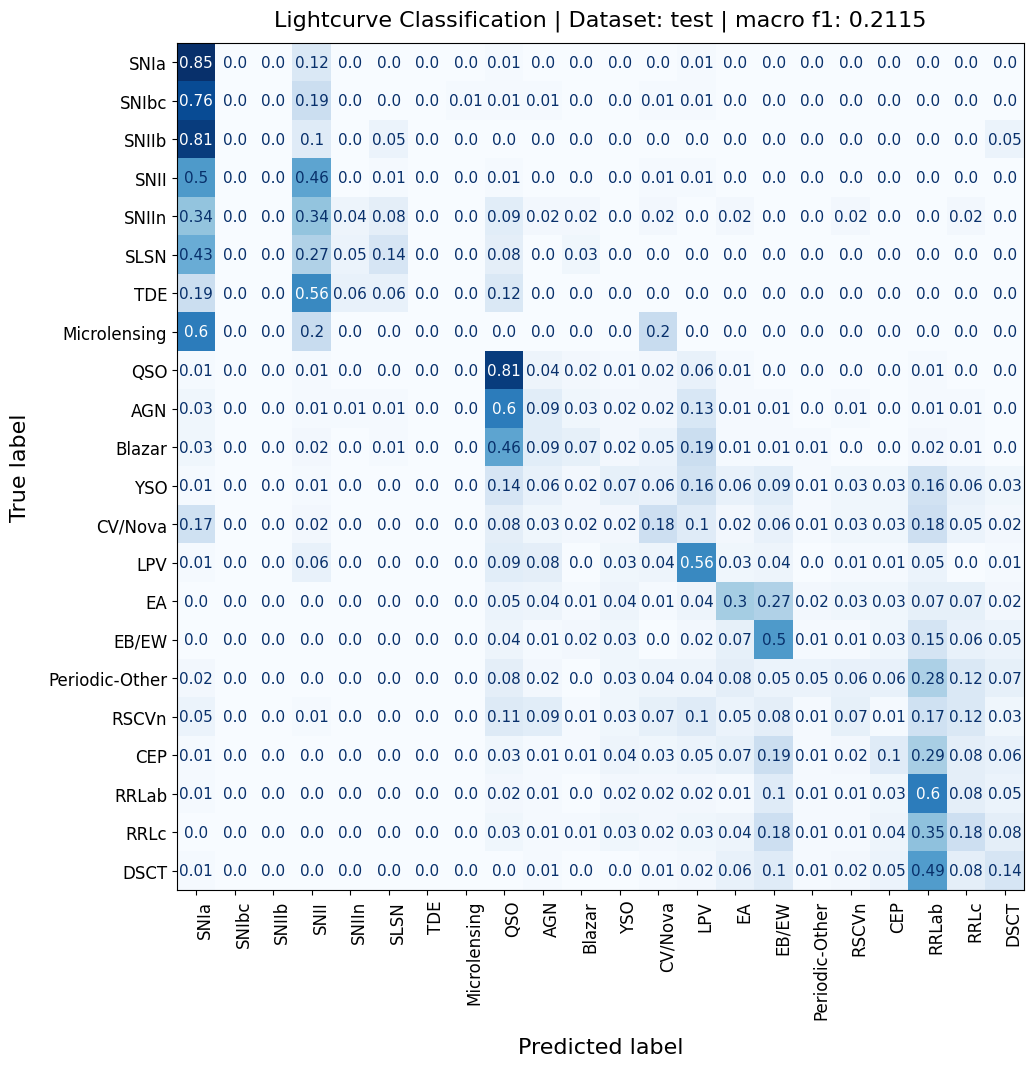

In [15]:
test = InitClassifier(path_to_config_yaml=PATH_1,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False


dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_1 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))

#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Lightcurve Classification | Dataset', order_classes=ztf_order_classes)


True False False
Using checkpoint 6112.ckpt
Using checkpoint 6112.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


  7%|▋         | 32/477 [00:00<00:03, 112.86it/s]

100%|██████████| 477/477 [00:03<00:00, 146.59it/s]


                precision    recall  f1-score   support

           AGN     0.3906    0.2986    0.3384       556
           QSO     0.4940    0.6474    0.5604       570
            EA     0.6412    0.6772    0.6587       570
           YSO     0.3467    0.2669    0.3016       487
          SNIa     0.5759    0.6887    0.6272       485
       CV/Nova     0.4949    0.4531    0.4731       320
          RRLc     0.3800    0.5536    0.4507       578
         RSCVn     0.2980    0.2027    0.2413       444
        Blazar     0.2759    0.2370    0.2550       270
          SNII     0.4632    0.4818    0.4723       274
         EB/EW     0.4346    0.6384    0.5172       578
           LPV     0.6030    0.8224    0.6958       580
           CEP     0.4606    0.2580    0.3307       566
         RRLab     0.5719    0.6357    0.6021       582
Periodic-Other     0.1429    0.0458    0.0694       240
          DSCT     0.2881    0.1678    0.2121       304
         SNIbc     0.2500    0.0233    0.0426  

<Axes: title={'center': 'Lightcurve Classification | Dataset: test | macro f1: 0.3229'}, xlabel='Predicted label', ylabel='True label'>

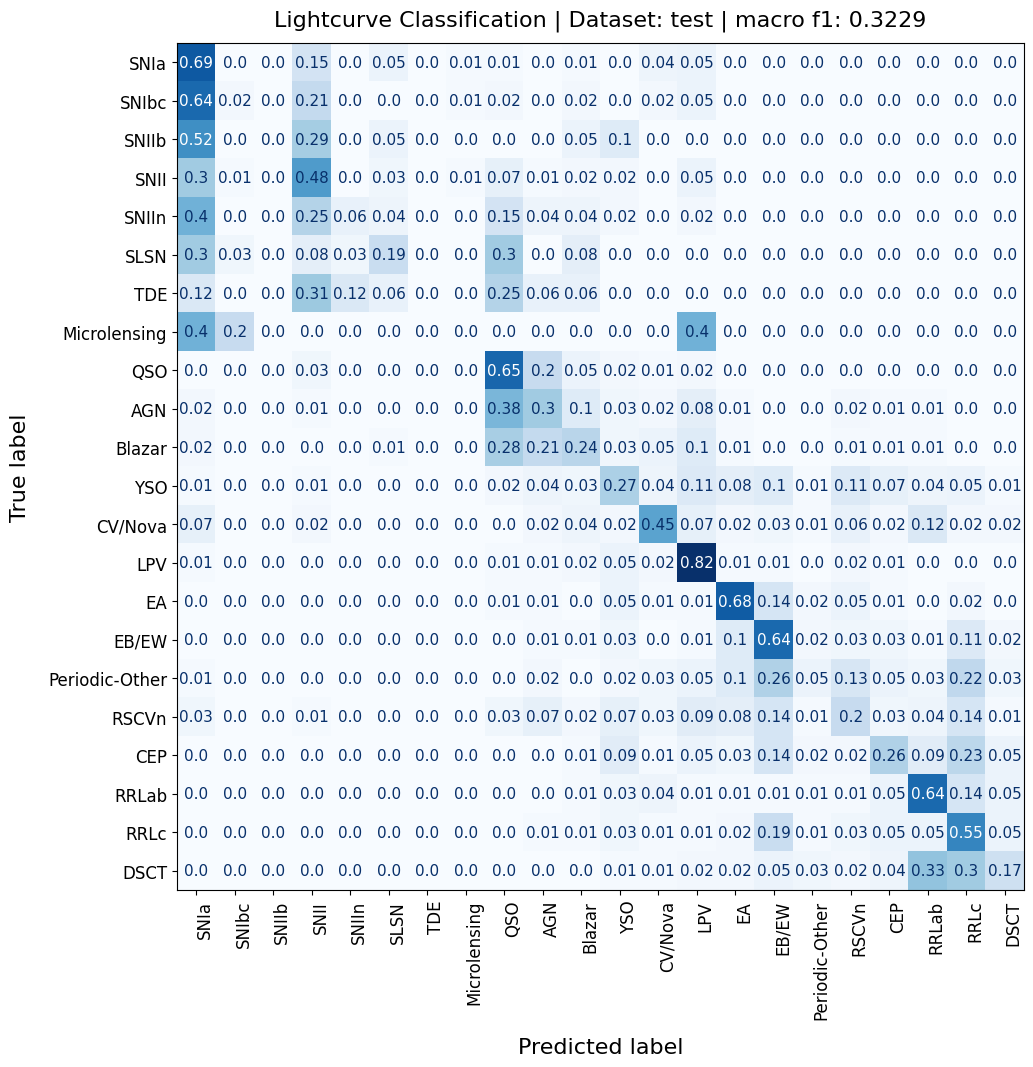

In [16]:
test = InitClassifier(path_to_config_yaml=PATH_2,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False


dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_2 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))

#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Lightcurve Classification | Dataset', order_classes=ztf_order_classes)


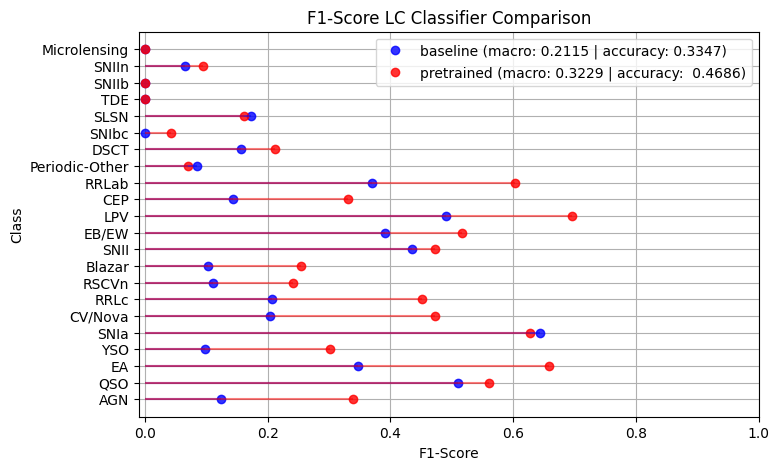

baseline f1 mean:
trans 0.1642767796470787
stoch 0.20756944921900583
per 0.2556517779568208
pretrained f1 mean:
trans 0.16952668907591922
stoch 0.2966329291081625
per 0.3377131505131816


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
       # print(key,value)
        if key in ZTF_TAXONOMY().keys():

            f1_baseline.append(value['f1-score'])

    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])

    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)

    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report_1,report_2)

transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}

periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}
import numpy as np
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_1.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():

        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('baseline f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))
for class_key, value in report_2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():

        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('pretrained f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

In [13]:
t_ = 1import pandas as pd

df = pd.DataFrame({'true':val_true, 'pred':np.argmax(val_preds, axis = -1)})

transient_dict = ZTF_TAXONOMY.transient.group
transients = df.query('true in {}'.format(list(transient_dict.values())))
print(classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=False))

##
stochastic_dict = ZTF_TAXONOMY.stochastic.group
stochastics = df.query('true in {}'.format(list(stochastic_dict.values())))
print(classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=False))
####
periodic_dict = ZTF_TAXONOMY.periodic.group
periodics = df.query('true in {}'.format(list(periodic_dict.values())))
print(classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=False))


sum([classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score']])/3

SyntaxError: invalid decimal literal (2231043161.py, line 1)

In [ ]:
test = InitClassifier(path_to_config_yaml=PATH_2,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
import numpy as np
from sklearn.metrics import classification_report
val_preds, val_true =test.predict_by_time(dl.test_dataset, DEVICE,eval_times = [t_]) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)


True False False
Using checkpoint 4848.ckpt
Using checkpoint 4848.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


  0%|          | 0/477 [00:00<?, ?it/s]


In [23]:
import torch

# Example tensor
bsz, seqlen, channels = 2, 5, 3
x = torch.randn(bsz, seqlen, channels)

dt = 0.2

# find min per sample (over seqlen & channels)
min_vals, _ = x.view(bsz, -1).min(dim=1)   # shape [bsz]

# reshape for broadcasting: [bsz, 1, 1]
min_vals = min_vals.view(bsz, 1, 1)

# compute mask
mask = x < (min_vals + dt)

print("x shape:", x)
print("mask shape:", mask)


x shape: tensor([[[ 3.0852e-01, -4.1230e-01, -3.1842e-01],
         [ 8.0920e-04,  4.6384e-02, -5.4418e-01],
         [-7.0441e-01, -7.7820e-01, -9.5111e-01],
         [-5.2094e-01,  7.6540e-02,  1.5215e-01],
         [ 2.2895e+00,  1.1036e+00,  1.2113e+00]],

        [[-4.2369e-02, -7.3361e-02,  6.4931e-01],
         [-3.5681e-01, -2.1312e+00, -2.7035e+00],
         [ 1.0417e-01, -1.2709e+00, -1.2558e+00],
         [-6.2700e-01, -2.2226e+00, -9.7979e-01],
         [ 4.0984e-01, -1.1913e+00, -2.1165e-01]]])
mask shape: tensor([[[False, False, False],
         [False, False, False],
         [False,  True,  True],
         [False, False, False],
         [False, False, False]],

        [[False, False, False],
         [False, False,  True],
         [False, False, False],
         [False, False, False],
         [False, False, False]]])


In [24]:
report_2 = classification_report(val_true, np.argmax(val_preds[t_], axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds[t_], axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds[t_], axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Finetuned Lightcurve Classification | Dataset', order_classes=list(ZTF_TAXONOMY().keys()))


ValueError: attempt to get argmax of an empty sequence